# MACHINE LEARNING 
### STEPS REQUIRED TO BUILD ML MODEL
###### 1.import all libraries(numpy, pandas, matplotlib,sckit-learn,tensorflow,keras)
###### 2.data import using pandas(pd.read_CSV,pd.read_excel)
###### 3.EDA (pre-processing/data cleaning/modeling/scaling/tranforming)
###### 4.data divide inot two parts => training and testing (train_test_split),80for training , 20 for testing 
###### 5.import model 
###### 6.training data fitted into model 
###### 7.make predictions(.predict) 
###### 8.check the evaluation 
###### 9. covert into pkl file 
###### 10.make gui

### "Given information about a house and its surrounding area, can you estimate its selling price?"
==> algo used: linear regression 
==> target: price 

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score 

In [4]:
df=pd.read_csv("USA_Housing.csv")

In [7]:
df.head() # first 5 rows

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price,Address
0,79545.458574,5.682861,7.009188,4.09,23086.800503,1.059034e+06,"208 Michael Ferry Apt. 674\nLaurabury, NE 3701..."
1,79248.642455,6.002900,6.730821,3.09,40173.072174,1.505891e+06,"188 Johnson Views Suite 079\nLake Kathleen, CA..."
2,61287.067179,5.865890,8.512727,5.13,36882.159400,1.058988e+06,"9127 Elizabeth Stravenue\nDanieltown, WI 06482..."
3,63345.240046,7.188236,5.586729,3.26,34310.242831,1.260617e+06,USS Barnett\nFPO AP 44820
4,59982.197226,5.040555,7.839388,4.23,26354.109472,6.309435e+05,USNS Raymond\nFPO AE 09386


In [8]:
df.tail() # last five rows

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price,Address
4995,60567.944140,7.830362,6.137356,3.46,22837.361035,1.060194e+06,USNS Williams\nFPO AP 30153-7653
4996,78491.275435,6.999135,6.576763,4.02,25616.115489,1.482618e+06,"PSC 9258, Box 8489\nAPO AA 42991-3352"
4997,63390.686886,7.250591,4.805081,2.13,33266.145490,1.030730e+06,"4215 Tracy Garden Suite 076\nJoshualand, VA 01..."
4998,68001.331235,5.534388,7.130144,5.44,42625.620156,1.198657e+06,USS Wallace\nFPO AE 73316
4999,65510.581804,5.992305,6.792336,4.07,46501.283803,1.298950e+06,"37778 George Ridges Apt. 509\nEast Holly, NV 2..."


In [11]:
df.shape #(no. fo rows , no. columns)

(5000, 7)

In [13]:
df.columns #(features of data set)

Index(['Avg. Area Income', 'Avg. Area House Age', 'Avg. Area Number of Rooms',
       'Avg. Area Number of Bedrooms', 'Area Population', 'Price', 'Address'],
      dtype='object')

In [14]:
df.info() #information of data set 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 7 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Avg. Area Income              5000 non-null   float64
 1   Avg. Area House Age           5000 non-null   float64
 2   Avg. Area Number of Rooms     5000 non-null   float64
 3   Avg. Area Number of Bedrooms  5000 non-null   float64
 4   Area Population               5000 non-null   float64
 5   Price                         5000 non-null   float64
 6   Address                       5000 non-null   object 
dtypes: float64(6), object(1)
memory usage: 273.6+ KB


In [17]:
df.describe() 

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5.000000e+03
mean,68583.108984,5.977222,6.987792,3.981330,36163.516039,1.232073e+06
std,10657.991214,0.991456,1.005833,1.234137,9925.650114,3.531176e+05
min,17796.631190,2.644304,3.236194,2.000000,172.610686,1.593866e+04
25%,61480.562388,5.322283,6.299250,3.140000,29403.928702,9.975771e+05
50%,68804.286404,5.970429,7.002902,4.050000,36199.406689,1.232669e+06
75%,75783.338666,6.650808,7.665871,4.490000,42861.290769,1.471210e+06
max,107701.748378,9.519088,10.759588,6.500000,69621.713378,2.469066e+06


In [42]:
df.isnull().sum() #checks null value 

Avg. Area Income                0
Avg. Area House Age             0
Avg. Area Number of Rooms       0
Avg. Area Number of Bedrooms    0
Area Population                 0
Price                           0
Address                         0
dtype: int64

In [43]:
df.duplicated().sum() #checks duplicate value 

np.int64(0)

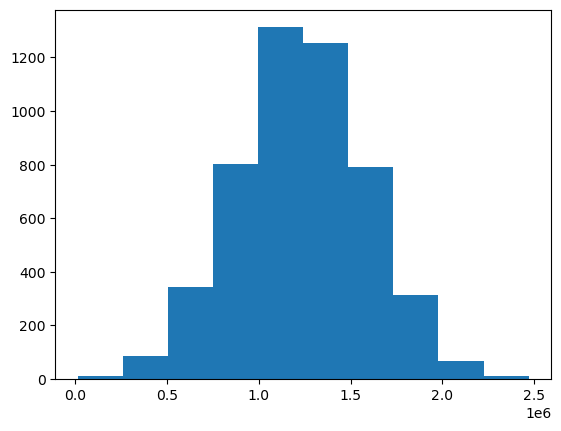

In [44]:
plt.hist(df["Price"])  #this tells that the price of majority of house lie btw 1 to 1.5
plt.show()

# scatter plots
#### tells whether there is a relation in btw a particular feature and our target(price), if yes then keep the feature, else remove it not needed in the model 

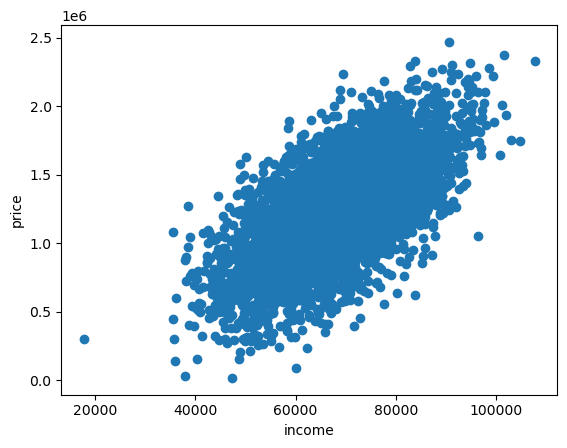

In [45]:
plt.scatter(df["Avg. Area Income"],df["Price"])
plt.xlabel("income")
plt.ylabel("price")
plt.show()

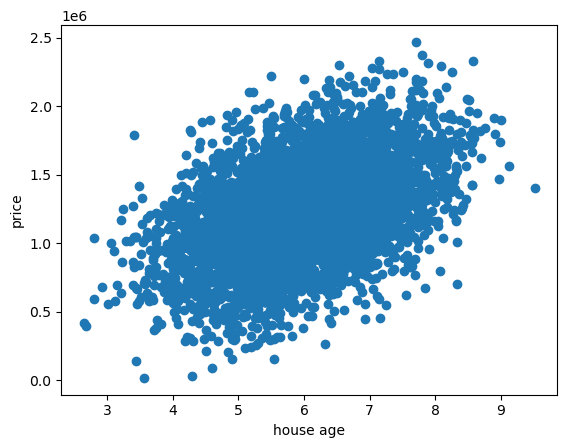

In [52]:
plt.scatter(df["Avg. Area House Age"],df["Price"])
plt.xlabel("house age")
plt.ylabel("price")
plt.show()

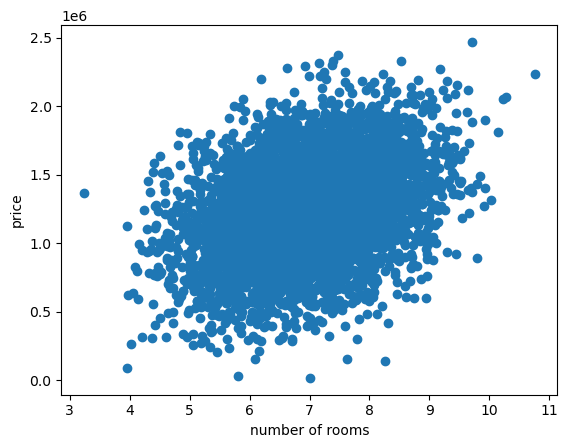

In [47]:
plt.scatter(df["Avg. Area Number of Rooms"],df["Price"])
plt.xlabel("number of rooms")
plt.ylabel("price")
plt.show()

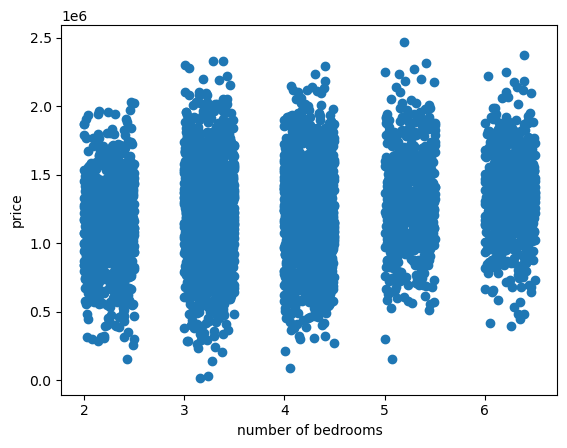

In [48]:
plt.scatter(df["Avg. Area Number of Bedrooms"],df["Price"])
plt.xlabel("number of bedrooms")
plt.ylabel("price")
plt.show()

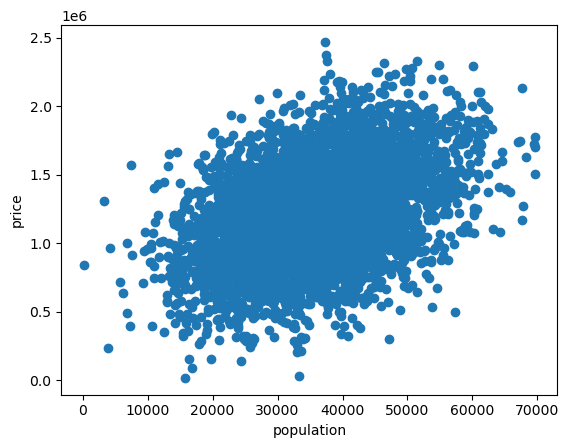

In [49]:
plt.scatter(df["Area Population"],df["Price"])
plt.xlabel("population")
plt.ylabel("price")
plt.show()

In [50]:
df.corr(numeric_only=True) #How strongly two variables move together.

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price
Avg. Area Income,1.000000,-0.002007,-0.011032,0.019788,-0.016234,0.639734
Avg. Area House Age,-0.002007,1.000000,-0.009428,0.006149,-0.018743,0.452543
Avg. Area Number of Rooms,-0.011032,-0.009428,1.000000,0.462695,0.002040,0.335664
Avg. Area Number of Bedrooms,0.019788,0.006149,0.462695,1.000000,-0.022168,0.171071
Area Population,-0.016234,-0.018743,0.002040,-0.022168,1.000000,0.408556
Price,0.639734,0.452543,0.335664,0.171071,0.408556,1.000000


In [73]:
df=df.drop("Address",axis=1)

In [74]:
X=df.drop("Price",axis=1)
y = df["Price"]

In [75]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [86]:
model = LinearRegression()
model.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [87]:
y_pred = model.predict(X_test)
comparison = pd.DataFrame({
    "Actual Price": y_test.values,
    "Predicted Price": y_pred
})

comparison.head(10)

,Actual Price,Predicted Price
0,1.339096e+06,1.308588e+06
1,1.251794e+06,1.237037e+06
2,1.340095e+06,1.243429e+06
3,1.431508e+06,1.228900e+06
4,1.042374e+06,1.063321e+06
5,1.555321e+06,1.544058e+06
6,1.250882e+06,1.094775e+06
7,1.039381e+06,8.332847e+05
8,8.324752e+05,7.884129e+05
9,1.420648e+06,1.469715e+06


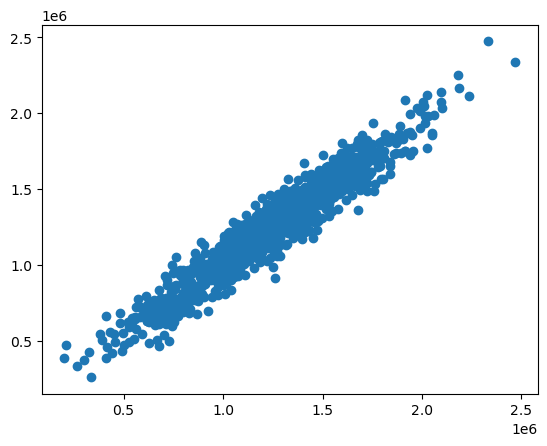

In [84]:
plt.scatter(y_test,y_pred)
plt.show()

In [85]:
r2 = r2_score(y_test, y_pred) #How much of the variation in house prices is explained by the model?
print(r2)

0.9179971706834579


In [88]:
import joblib #now we will save our ml model
joblib.dump(model,"house_price_model.pkl")

['house_price_model.pkl']